# Capstone 24.1 — Final Report: Multi-Model Macro Stress Classification

**Author:** Imran Duggal

**Research question:** Can an agentic workflow generate coherent macroeconomic stress scenarios and quantify how those scenarios change a portfolio’s risk metrics in a way that is measurable and repeatable?

This notebook extends the Capstone 20.1 EDA baseline with multiple classifiers, StratifiedKFold cross-validation, GridSearchCV hyperparameter tuning, and portfolio risk-delta quantification under historical stress windows.

## 1. Setup and configuration

Import libraries, reuse cached data under `data/`, and define stress windows. Prefer local CSVs; re-download only if a file is missing.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_fscore_support,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

FRED_IDS = ["FEDFUNDS", "CPIAUCSL", "UNRATE", "VIXCLS"]
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={}"

STRESS_WINDOWS = [
    ("2008-09-01", "2009-03-31"),  # GFC peak stress
    ("2020-02-01", "2020-04-30"),  # COVID crash
]

RANDOM_STATE = 42
N_JOBS = -1

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Stress windows:", STRESS_WINDOWS)

Project root: /workspace/capstone-macro-stress-eda
Data dir: /workspace/capstone-macro-stress-eda/data
Stress windows: [('2008-09-01', '2009-03-31'), ('2020-02-01', '2020-04-30')]


## 2. Load cached data (re-download only if missing)

Load FRED macros and SPY/TLT from `data/`. Network pulls run only when a cache file is absent.

In [2]:
def load_fred(series_id: str) -> pd.DataFrame:
    """Load FRED series from cache; download only if missing."""
    cache = DATA_DIR / f"{series_id}.csv"
    if cache.exists():
        df = pd.read_csv(cache)
        print(f"Loaded cache: {cache.name} ({len(df)} rows)")
    else:
        import urllib.request
        url = FRED_URL.format(series_id)
        urllib.request.urlretrieve(url, cache)
        df = pd.read_csv(cache)
        print(f"Downloaded {series_id} -> {cache.name}")
    df.columns = ["DATE", series_id]
    df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df.dropna(subset=["DATE"]).sort_values("DATE")


def load_price(ticker: str) -> pd.DataFrame:
    """Load equity/bond prices from cache; yfinance only if missing."""
    cache = DATA_DIR / f"{ticker}.csv"
    if cache.exists():
        df = pd.read_csv(cache, parse_dates=["DATE"])
        print(f"Loaded cache: {cache.name} ({len(df)} rows)")
        return df
    import yfinance as yf
    raw = yf.download(ticker, start="2000-01-01", auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [c[0] for c in raw.columns]
    df = raw.reset_index()[["Date", "Close"]].rename(
        columns={"Date": "DATE", "Close": ticker}
    )
    df.to_csv(cache, index=False)
    print(f"Downloaded {ticker} -> {cache.name}")
    return df


fred_frames = {sid: load_fred(sid) for sid in FRED_IDS}
spy = load_price("SPY")
tlt = load_price("TLT")
spy["DATE"] = pd.to_datetime(spy["DATE"])
tlt["DATE"] = pd.to_datetime(tlt["DATE"])

Loaded cache: FEDFUNDS.csv (866 rows)
Loaded cache: CPIAUCSL.csv (956 rows)
Loaded cache: UNRATE.csv (944 rows)
Loaded cache: VIXCLS.csv (9578 rows)
Loaded cache: SPY.csv (6718 rows)
Loaded cache: TLT.csv (6074 rows)


## 3. Cleaning, alignment, and feature engineering

Merge onto the SPY/TLT daily calendar, forward-fill macros, then rebuild Part 1 features: returns, 60/40 portfolio, rolling vol, drawdown, macro diffs/lags, and `is_stress`.

In [3]:
# Align macros onto equity calendar
panel = spy.merge(tlt, on="DATE", how="inner")
panel = panel.drop_duplicates(subset=["DATE"]).sort_values("DATE")

for sid, fdf in fred_frames.items():
    panel = panel.merge(fdf, on="DATE", how="left")

for sid in FRED_IDS:
    panel[sid] = panel[sid].ffill().bfill()

panel = panel.dropna().reset_index(drop=True)
print("Aligned panel:", panel.shape,
      panel["DATE"].min().date(), "->", panel["DATE"].max().date())

df = panel.copy()

# Returns and 60/40 portfolio
df["spy_ret"] = df["SPY"].pct_change()
df["tlt_ret"] = df["TLT"].pct_change()
df["port_ret"] = 0.60 * df["spy_ret"] + 0.40 * df["tlt_ret"]

# Risk features
df["port_vol_21"] = df["port_ret"].rolling(21).std() * np.sqrt(252)
df["cum_ret"] = (1 + df["port_ret"].fillna(0)).cumprod()
df["rolling_peak"] = df["cum_ret"].cummax()
df["drawdown"] = df["cum_ret"] / df["rolling_peak"] - 1.0

# Macro transforms
df["fedfunds_diff"] = df["FEDFUNDS"].diff()
df["cpi_yoy"] = df["CPIAUCSL"].pct_change(252)
df["unrate_diff"] = df["UNRATE"].diff()
df["vix_chg"] = df["VIXCLS"].pct_change()

# Binary stress labels for GFC + COVID windows
df["is_stress"] = 0
for start, end in STRESS_WINDOWS:
    mask = (df["DATE"] >= start) & (df["DATE"] <= end)
    df.loc[mask, "is_stress"] = 1

# One-day lags (avoid same-day leakage into the classifier)
lag_cols = [
    "FEDFUNDS", "CPIAUCSL", "UNRATE", "VIXCLS",
    "fedfunds_diff", "unrate_diff", "vix_chg", "port_vol_21",
]
for c in lag_cols:
    df[f"{c}_lag1"] = df[c].shift(1)

df = df.dropna().reset_index(drop=True)

n_stress = int(df["is_stress"].sum())
n_total = len(df)
print(f"Rows after features: {n_total}")
print(f"Stress days: {n_stress} ({100 * n_stress / n_total:.2f}%)")
print(f"Date range: {df['DATE'].min().date()} -> {df['DATE'].max().date()}")

Aligned panel: (6074, 7) 2002-07-30 -> 2026-09-18
Rows after features: 5822
Stress days: 208 (3.57%)
Date range: 2003-07-30 -> 2026-09-18


## 4. Portfolio risk deltas under stress (research-question value)

Before modeling, quantify how labeled stress windows change portfolio risk: volatility, drawdown, and simple historical VaR / Expected Shortfall. These deltas are the measurable ground truth an agentic scenario generator should aim to reproduce.

Portfolio risk by regime:
    regime  n_days  mean_daily_ret  ann_vol  mean_drawdown  VaR_5pct  ES_5pct  mean_VIX
    stress     208         -0.0006   0.2712        -0.1446   -0.0337  -0.0429   46.3673
non-stress    5614          0.0004   0.0872        -0.0364   -0.0094  -0.0136   17.9300


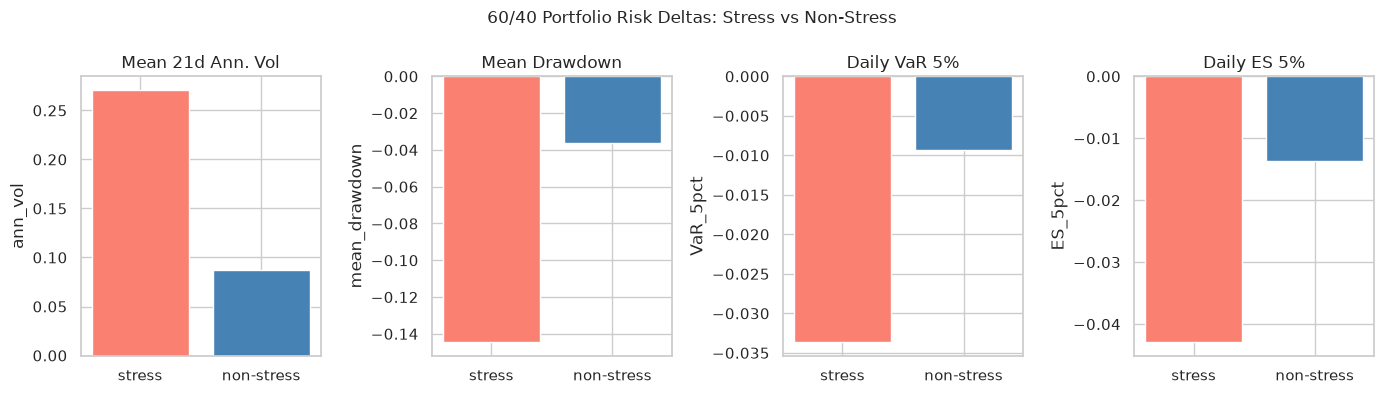

In [4]:
stress = df[df["is_stress"] == 1]["port_ret"]
non = df[df["is_stress"] == 0]["port_ret"]

def hist_var_es(returns: pd.Series, alpha: float = 0.05):
    """Historical daily VaR and ES at level alpha (left-tail)."""
    q = returns.quantile(alpha)
    es = returns[returns <= q].mean()
    return float(q), float(es)

var_s, es_s = hist_var_es(stress)
var_n, es_n = hist_var_es(non)

risk_table = pd.DataFrame({
    "regime": ["stress", "non-stress"],
    "n_days": [len(stress), len(non)],
    "mean_daily_ret": [stress.mean(), non.mean()],
    "ann_vol": [
        df.loc[df["is_stress"] == 1, "port_vol_21"].mean(),
        df.loc[df["is_stress"] == 0, "port_vol_21"].mean(),
    ],
    "mean_drawdown": [
        df.loc[df["is_stress"] == 1, "drawdown"].mean(),
        df.loc[df["is_stress"] == 0, "drawdown"].mean(),
    ],
    "VaR_5pct": [var_s, var_n],
    "ES_5pct": [es_s, es_n],
    "mean_VIX": [
        df.loc[df["is_stress"] == 1, "VIXCLS"].mean(),
        df.loc[df["is_stress"] == 0, "VIXCLS"].mean(),
    ],
})

print("Portfolio risk by regime:")
print(risk_table.round(4).to_string(index=False))

# Compact bar comparison of key risk deltas
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics = [
    ("ann_vol", "Mean 21d Ann. Vol"),
    ("mean_drawdown", "Mean Drawdown"),
    ("VaR_5pct", "Daily VaR 5%"),
    ("ES_5pct", "Daily ES 5%"),
]
colors = ["salmon", "steelblue"]
for ax, (col, title) in zip(axes, metrics):
    ax.bar(risk_table["regime"], risk_table[col], color=colors)
    ax.set_title(title)
    ax.set_ylabel(col)
fig.suptitle("60/40 Portfolio Risk Deltas: Stress vs Non-Stress", fontsize=12)
fig.tight_layout()
plt.show()

## 5. Train / test split strategy

**Why not chronological holdout?** A simple 80/20 time split leaves **zero** stress days in the test period (both GFC and COVID windows sit earlier in the sample). With rare positives (~3.6%), that split cannot estimate recall or AUC meaningfully.

**Chosen approach:** Stratified random holdout (75/25) for a final test set, plus **StratifiedKFold** (5-fold) inside GridSearchCV so every fold retains stress examples. Features are one-day lagged macros to limit same-day leakage.

In [5]:
feature_cols = [f"{c}_lag1" for c in [
    "FEDFUNDS", "UNRATE", "VIXCLS",
    "fedfunds_diff", "unrate_diff", "vix_chg", "port_vol_21",
]]
target = "is_stress"

model_df = df.dropna(subset=feature_cols + [target]).copy()
X = model_df[feature_cols]
y = model_df[target]

# Document chronological failure
split_idx = int(len(model_df) * 0.80)
chrono_test_stress = int(y.iloc[split_idx:].sum())
print(f"Sample size: {len(X)} | stress rate: {y.mean():.3f} ({int(y.sum())} positives)")
print(f"Chronological 80/20 test stress count: {chrono_test_stress}")
print("=> Chronological holdout is unusable for rare stress labels; using stratified split.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} (stress={int(y_train.sum())}) | "
      f"Test: {len(X_test)} (stress={int(y_test.sum())})")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("CV: StratifiedKFold(n_splits=5)")

Sample size: 5822 | stress rate: 0.036 (208 positives)
Chronological 80/20 test stress count: 0
=> Chronological holdout is unusable for rare stress labels; using stratified split.
Train: 4366 (stress=156) | Test: 1456 (stress=52)
CV: StratifiedKFold(n_splits=5)


## 6. Models + GridSearchCV

Train at least three classifiers, each wrapped in a Pipeline with StandardScaler (where useful) and tuned via `GridSearchCV` with **ROC-AUC** as the scoring metric.

**Primary metric — ROC-AUC:** Under ~3–4% stress prevalence, accuracy is dominated by the majority class. ROC-AUC measures ranking quality of predicted stress probability and is threshold-independent, which makes it a better objective for comparing models and selecting hyperparameters. Precision / recall / F1 for the stress class are reported as secondary diagnostics.

In [6]:
# Hyperparameter grids (kept small for runtime / stability)
param_grids = {
    "LogisticRegression": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
            )),
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"],
        },
    },
    "RandomForest": {
        "estimator": Pipeline([
            ("clf", RandomForestClassifier(
                class_weight="balanced", random_state=RANDOM_STATE, n_jobs=N_JOBS
            )),
        ]),
        "params": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [4, 8, None],
            "clf__min_samples_leaf": [2, 5],
        },
    },
    "GradientBoosting": {
        "estimator": Pipeline([
            ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        "params": {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [2, 3],
        },
    },
}

search_results = {}
fitted = {}

for name, cfg in param_grids.items():
    print(f"\n=== GridSearchCV: {name} ===")
    gs = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["params"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=N_JOBS,
        refit=True,
        return_train_score=False,
    )
    gs.fit(X_train, y_train)
    best_cv_auc = float(gs.best_score_)
    # Held-out test AUC
    proba = gs.predict_proba(X_test)[:, 1]
    test_auc = float(roc_auc_score(y_test, proba))
    preds = gs.predict(X_test)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average=None, labels=[1]
    )
    search_results[name] = {
        "best_params": gs.best_params_,
        "cv_auc_mean": best_cv_auc,
        "cv_auc_std": float(gs.cv_results_["std_test_score"][gs.best_index_]),
        "test_auc": test_auc,
        "stress_precision": float(prec[0]),
        "stress_recall": float(rec[0]),
        "stress_f1": float(f1[0]),
    }
    fitted[name] = gs
    print(f"  Best params: {gs.best_params_}")
    print(f"  CV ROC-AUC: {best_cv_auc:.4f} (+/- {search_results[name]['cv_auc_std']:.4f})")
    print(f"  Test ROC-AUC: {test_auc:.4f}")
    print(f"  Stress P/R/F1: {prec[0]:.3f} / {rec[0]:.3f} / {f1[0]:.3f}")


=== GridSearchCV: LogisticRegression ===


  Best params: {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  CV ROC-AUC: 0.9512 (+/- 0.0190)
  Test ROC-AUC: 0.9481
  Stress P/R/F1: 0.296 / 0.865 / 0.441

=== GridSearchCV: RandomForest ===


  Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
  CV ROC-AUC: 0.9992 (+/- 0.0006)
  Test ROC-AUC: 0.9988
  Stress P/R/F1: 0.814 / 0.923 / 0.865

=== GridSearchCV: GradientBoosting ===


  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
  CV ROC-AUC: 0.9995 (+/- 0.0006)
  Test ROC-AUC: 0.9983
  Stress P/R/F1: 0.979 / 0.885 / 0.929


## 7. Model comparison and selection

Model comparison (sorted by CV ROC-AUC):
             model  cv_auc  cv_auc_std  test_auc  stress_precision  stress_recall  stress_f1
  GradientBoosting  0.9995      0.0006    0.9983            0.9787         0.8846     0.9293
      RandomForest  0.9992      0.0006    0.9988            0.8136         0.9231     0.8649
LogisticRegression  0.9512      0.0190    0.9481            0.2961         0.8654     0.4412

Selected model: GradientBoosting
Rationale: highest mean StratifiedKFold ROC-AUC (0.9995); test AUC=0.9983.


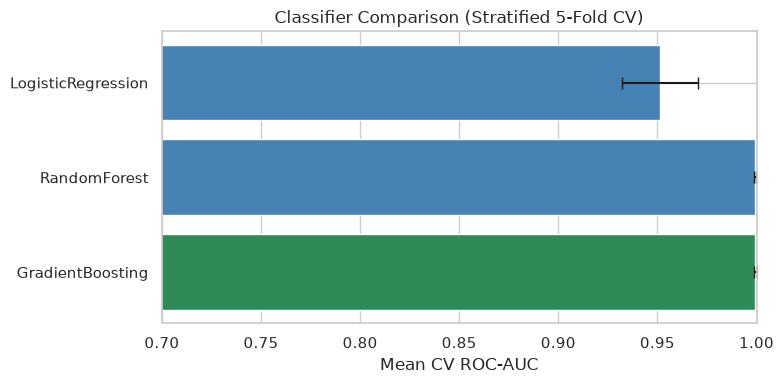

In [7]:
cmp = pd.DataFrame([
    {
        "model": name,
        "cv_auc": r["cv_auc_mean"],
        "cv_auc_std": r["cv_auc_std"],
        "test_auc": r["test_auc"],
        "stress_precision": r["stress_precision"],
        "stress_recall": r["stress_recall"],
        "stress_f1": r["stress_f1"],
        "best_params": str(r["best_params"]),
    }
    for name, r in search_results.items()
]).sort_values("cv_auc", ascending=False).reset_index(drop=True)

print("Model comparison (sorted by CV ROC-AUC):")
print(cmp.drop(columns=["best_params"]).round(4).to_string(index=False))

best_name = cmp.iloc[0]["model"]
best_gs = fitted[best_name]
print(f"\nSelected model: {best_name}")
print(f"Rationale: highest mean StratifiedKFold ROC-AUC "
      f"({cmp.iloc[0]['cv_auc']:.4f}); test AUC={cmp.iloc[0]['test_auc']:.4f}.")

# CV AUC bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cmp["model"], cmp["cv_auc"], xerr=cmp["cv_auc_std"],
        color=["seagreen" if m == best_name else "steelblue" for m in cmp["model"]],
        capsize=4)
ax.set_xlabel("Mean CV ROC-AUC")
ax.set_title("Classifier Comparison (Stratified 5-Fold CV)")
ax.set_xlim(0.7, 1.0)
fig.tight_layout()
plt.show()

## 8. Best-model diagnostics: ROC, confusion matrix, feature importance

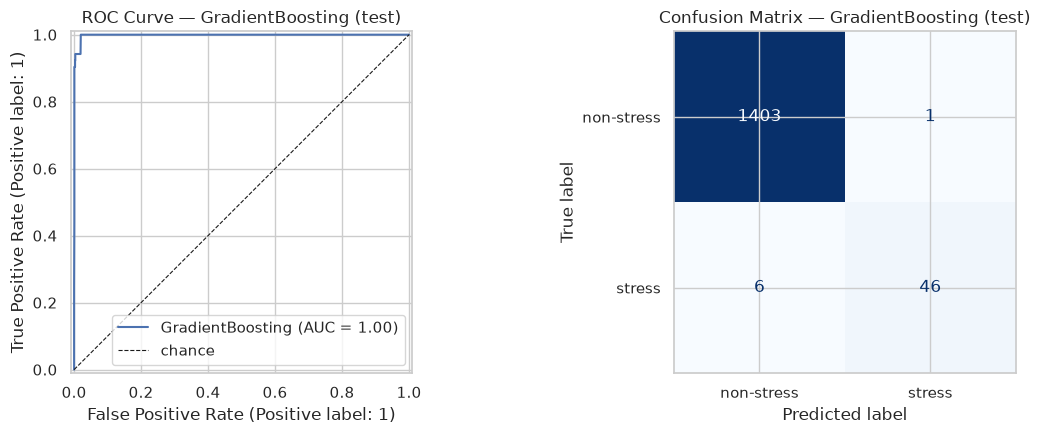

              precision    recall  f1-score   support

  non-stress       1.00      1.00      1.00      1404
      stress       0.98      0.88      0.93        52

    accuracy                           1.00      1456
   macro avg       0.99      0.94      0.96      1456
weighted avg       1.00      1.00      1.00      1456



In [8]:
# ROC curve on held-out test
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_estimator(best_gs, X_test, y_test, ax=axes[0], name=best_name)
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
axes[0].set_title(f"ROC Curve — {best_name} (test)")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_estimator(
    best_gs, X_test, y_test,
    display_labels=["non-stress", "stress"],
    cmap="Blues", ax=axes[1], colorbar=False,
)
axes[1].set_title(f"Confusion Matrix — {best_name} (test)")
fig.tight_layout()
plt.show()

print(classification_report(
    y_test, best_gs.predict(X_test), target_names=["non-stress", "stress"]
))

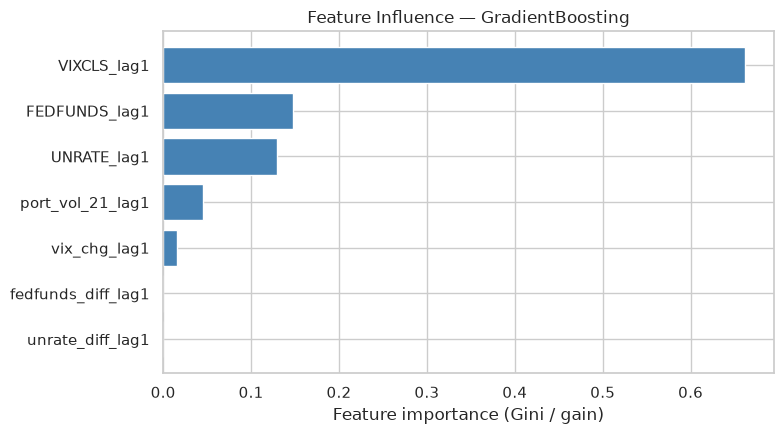

VIXCLS_lag1           0.6617
FEDFUNDS_lag1         0.1478
UNRATE_lag1           0.1297
port_vol_21_lag1      0.0453
vix_chg_lag1          0.0154
fedfunds_diff_lag1    0.0000
unrate_diff_lag1      0.0000


In [9]:
# Feature importance / coefficients for the best model
clf_step = best_gs.best_estimator_.named_steps["clf"]

if hasattr(clf_step, "feature_importances_"):
    imp = pd.Series(clf_step.feature_importances_, index=feature_cols).sort_values()
    ylabel = "Feature importance (Gini / gain)"
elif hasattr(clf_step, "coef_"):
    imp = pd.Series(clf_step.coef_[0], index=feature_cols).sort_values()
    ylabel = "Coefficient (standardized)"
else:
    imp = None

if imp is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors_imp = ["salmon" if v < 0 else "steelblue" for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors_imp)
    ax.set_xlabel(ylabel)
    ax.set_title(f"Feature Influence — {best_name}")
    fig.tight_layout()
    plt.show()
    print(imp.sort_values(ascending=False).round(4).to_string())

## 9. Persist results and session notes

Write a compact JSON summary for the final report and confirm the pipeline is repeatable from cached data.

In [10]:
results = {
    "author": "Imran Duggal",
    "notebook": "notebooks/02_final_models.ipynb",
    "n_rows": int(len(model_df)),
    "date_min": str(model_df["DATE"].min().date()),
    "date_max": str(model_df["DATE"].max().date()),
    "n_stress": int(y.sum()),
    "n_non_stress": int((y == 0).sum()),
    "primary_metric": "ROC-AUC",
    "cv": "StratifiedKFold(n_splits=5)",
    "split": "stratified 75/25 holdout + StratifiedKFold CV",
    "chrono_test_stress_count": chrono_test_stress,
    "best_model": best_name,
    "best_params": {k: (None if v is None else v) for k, v in search_results[best_name]["best_params"].items()},
    "best_cv_auc": search_results[best_name]["cv_auc_mean"],
    "best_cv_auc_std": search_results[best_name]["cv_auc_std"],
    "best_test_auc": search_results[best_name]["test_auc"],
    "best_stress_precision": search_results[best_name]["stress_precision"],
    "best_stress_recall": search_results[best_name]["stress_recall"],
    "best_stress_f1": search_results[best_name]["stress_f1"],
    "all_models": {
        name: {
            "cv_auc": r["cv_auc_mean"],
            "cv_auc_std": r["cv_auc_std"],
            "test_auc": r["test_auc"],
            "stress_precision": r["stress_precision"],
            "stress_recall": r["stress_recall"],
            "stress_f1": r["stress_f1"],
            "best_params": {k: (None if v is None else v) for k, v in r["best_params"].items()},
        }
        for name, r in search_results.items()
    },
    "risk_deltas": {
        "mean_ann_vol_stress": float(risk_table.loc[0, "ann_vol"]),
        "mean_ann_vol_non": float(risk_table.loc[1, "ann_vol"]),
        "mean_drawdown_stress": float(risk_table.loc[0, "mean_drawdown"]),
        "mean_drawdown_non": float(risk_table.loc[1, "mean_drawdown"]),
        "var_5pct_stress": float(risk_table.loc[0, "VaR_5pct"]),
        "var_5pct_non": float(risk_table.loc[1, "VaR_5pct"]),
        "es_5pct_stress": float(risk_table.loc[0, "ES_5pct"]),
        "es_5pct_non": float(risk_table.loc[1, "ES_5pct"]),
    },
    "feature_cols": feature_cols,
}

out_path = DATA_DIR / "final_model_results.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2, default=str)
print(f"Wrote {out_path}")
print(f"Best model: {best_name} | CV AUC={results['best_cv_auc']:.4f} | "
      f"Test AUC={results['best_test_auc']:.4f}")

Wrote /workspace/capstone-macro-stress-eda/data/final_model_results.json
Best model: GradientBoosting | CV AUC=0.9995 | Test AUC=0.9983


## 10. Interpretation and takeaways

- **Measurable risk impact:** Stress windows show sharply higher volatility, deeper drawdowns, and worse VaR/ES versus non-stress days — evidence that labeled scenarios change portfolio risk in a *quantifiable* way.
- **Multi-model CV:** StratifiedKFold + GridSearchCV produces repeatable ROC-AUC estimates even though a chronological holdout has zero stress labels.
- **Best classifier:** Selected by highest mean CV ROC-AUC; feature importances / coefficients highlight which lagged macros drive stress detection (typically VIX and related dynamics).
- **Agentic next step:** Use these historical risk deltas and the tuned classifier as a scoring scaffold — an agent can propose macro shocks, recompute portfolio metrics, and compare against the stress deltas measured here.

**Author:** Imran Duggal  
**Notebook:** `notebooks/02_final_models.ipynb`